# 03 – N-gram language models

Unigram, add-one (Laplace) and interpolated Kneser-Ney (KN) models for next-word prediction, trained on the **train split only**, tuned on **validation**, and evaluated on **test exactly once** for the selected model and the KN bigram baseline.

- Code: `src/ngram.py` (models, numpy only), `src/evaluate.py` (shared evaluator for all models), tests in `tests/`.
- Data: `data/processed/{train,val,test}.txt` through `src/data.py` and the train vocabulary `data/processed/vocab.json` (14.7k entries, `<unk>`-mapped, punctuation kept as tokens).
- **Main comparison protocol:** the context is the *current sentence only*, padded with `<s>` (an option `context="cross"` prepends previous sentences of the same work; used here only as a sanity check).
- **Metrics** (`src/evaluate.py`): perplexity over **all** tokens (incl. `</s>`, `<unk>`, `<num>`, punctuation); top-1/3/5 accuracy and MRR over **word targets only** (`<unk>`, `<num>`, `</s>` and punctuation targets are not scored; `<s> </s> <unk> <num>` and punctuation are never suggested); the same metrics on the *archaic-keyword* targets (`tables/archaic_keywords.csv`, `is_archaic_candidate`); keystroke savings rate (KSR, 3 suggestions filtered by the typed prefix); latency per `next_word_probs` call.

In [1]:
import sys, json, pickle, time, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from src import data as D, ngram as N, evaluate as E

FIG_DIR, TAB_DIR, MODEL_DIR = ROOT / "figures", ROOT / "tables", ROOT / "models"
for d in (FIG_DIR, TAB_DIR, MODEL_DIR, ROOT / "results"):
    d.mkdir(exist_ok=True)
plt.rcParams.update({"figure.dpi": 100, "savefig.dpi": 200, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10})
BLUE, ORANGE, GREY = "#0072B2", "#D55E00", "#777777"


def save_fig(fig, name):
    fig.savefig(FIG_DIR / name, dpi=200, bbox_inches="tight")
    print(f"saved figure -> figures/{name}")


def save_table(df, name, index=False):
    df.to_csv(TAB_DIR / name, index=index, encoding="utf-8")
    print(f"saved table  -> tables/{name}")


vocab = D.load_vocab()
V = len(vocab)
train = D.load_split("train", vocab=vocab)
val = D.load_split("val", vocab=vocab)
print(f"vocabulary {V:,};  train {len(train):,} sentences, val {len(val):,}")

# results/metrics.csv is appended to by every evaluation; drop the rows of earlier runs of THIS
# notebook so that re-running it does not create duplicates (rows of other models, e.g. RNNs, stay)
METRICS = ROOT / "results" / "metrics.csv"
if METRICS.exists():
    old = pd.read_csv(METRICS)
    old[~old["model"].astype(str).str.match(r"^(unigram|laplace\d|kn\d)$")].to_csv(METRICS, index=False)

vocabulary 14,713;  train 53,331 sentences, val 7,857


## 1. Train the models
Interpolated KN of order *n* uses continuation counts for the lower orders, one absolute discount *d*, and full back-off to the lower order when a context was never seen; the lowest level is interpolated with the uniform distribution, so every vocabulary item has probability > 0. A call to `next_word_probs` adds the sparse higher-order terms to a precomputed unigram vector. Counting does not depend on *d*, so each model is trained once and *d* is changed afterwards. (Initial *d* = 0.75; tuned in §2.)

In [2]:
models, fit_time = {}, {}
specs = [("unigram", lambda: N.UnigramModel(V, vocab.bos_id)),
         ("laplace2", lambda: N.LaplaceNgram(2, V, vocab.bos_id)),
         ("laplace3", lambda: N.LaplaceNgram(3, V, vocab.bos_id))]
specs += [(f"kn{n}", (lambda n=n: N.KneserNeyNgram(n, V, vocab.bos_id, d=0.75))) for n in (2, 3, 4, 5)]
for name, make in specs:
    t = time.time()
    models[name] = make().fit(train)
    fit_time[name] = time.time() - t
size = pd.DataFrame({"model": list(models), "stored_ngrams": [m.num_ngrams() for m in models.values()],
                     "fit_seconds": [round(fit_time[k], 1) for k in models]})
display(size)

,model,stored_ngrams,fit_seconds
0,unigram,14712,0.1
1,laplace2,239035,0.3
2,laplace3,564421,0.3
3,kn2,253747,0.4
4,kn3,818168,0.6
5,kn4,1546000,0.9
6,kn5,2317836,1.2


## 2. Tune the discount *d* on validation (separately for each *n*)
Grid d ∈ {0.5, 0.6, 0.7, 0.75, 0.8, 0.9}; criterion = validation perplexity over all tokens. (Every evaluation is also logged to `results/metrics.csv`.)

d,0.5,0.6,0.7,0.75,0.8,0.9,best_d
n,,,,,,,
2,155.58,152.50,150.55,149.98,149.70,150.28,0.8
3,165.37,153.24,144.75,141.61,139.17,136.67,0.9
4,189.32,168.42,153.89,148.43,144.03,138.59,0.9
5,206.18,179.92,161.79,154.96,149.41,142.24,0.9


saved table  -> tables/ngram_discount_tuning.csv
tuned discounts: {2: 0.8, 3: 0.9, 4: 0.9, 5: 0.9}
saved figure -> figures/ngram_val_ppl_vs_discount.png


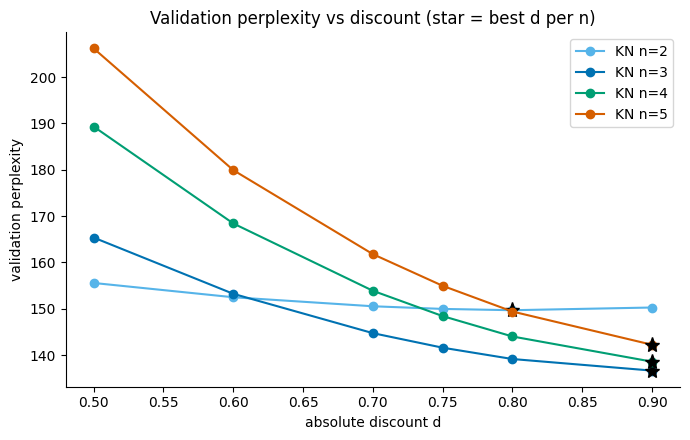

In [3]:
D_GRID = [0.5, 0.6, 0.7, 0.75, 0.8, 0.9]
rows = []
for n in (2, 3, 4, 5):
    m = models[f"kn{n}"]
    for d in D_GRID:
        m.d = d
        r = E.evaluate(m, "val", vocab, metrics="ppl")
        rows.append({"n": n, "d": d, "val_ppl": r["ppl"]})
tune = pd.DataFrame(rows)
pivot = tune.pivot(index="n", columns="d", values="val_ppl").round(2)
best_d = tune.loc[tune.groupby("n")["val_ppl"].idxmin()].set_index("n")["d"]
pivot["best_d"] = best_d
display(pivot)
save_table(tune, "ngram_discount_tuning.csv")
for n, d in best_d.items():
    models[f"kn{n}"].d = float(d)                      # keep the tuned discount
print("tuned discounts:", best_d.to_dict())

fig, ax = plt.subplots(figsize=(7, 4.5))
for n, c in zip((2, 3, 4, 5), ["#56B4E9", "#0072B2", "#009E73", "#D55E00"]):
    g = tune[tune["n"] == n]
    ax.plot(g["d"], g["val_ppl"], "o-", color=c, label=f"KN n={n}")
    ax.plot(best_d[n], g.loc[g["d"] == best_d[n], "val_ppl"], "*", color="k", ms=11)
ax.set_xlabel("absolute discount d"); ax.set_ylabel("validation perplexity")
ax.set_title("Validation perplexity vs discount (star = best d per n)")
ax.legend()
plt.tight_layout()
save_fig(fig, "ngram_val_ppl_vs_discount.png")
plt.show()

## 3. Validation results for all models (tuned *d*)
All metrics on the validation split. Perplexity covers every token; accuracy/MRR/KSR cover word targets only; "archaic" = targets that are archaic keywords.

In [4]:
order = ["unigram", "laplace2", "laplace3", "kn2", "kn3", "kn4", "kn5"]
val_rows = []
for name in order:
    r = E.evaluate(models[name], "val", vocab)
    r["num_ngrams"] = models[name].num_ngrams()
    val_rows.append(r)
val_df = pd.DataFrame(val_rows)
cols = ["model", "n", "hyperparameters", "ppl", "top1", "top3", "top5", "mrr", "ksr", "archaic_top1", "archaic_top3",
        "archaic_top5", "archaic_mrr", "archaic_ksr", "latency_ms", "num_ngrams", "n_word_targets", "n_archaic_targets"]
display(val_df[cols].round(4))
save_table(val_df[cols], "ngram_val_results.csv")

,model,n,hyperparameters,ppl,top1,top3,top5,mrr,ksr,archaic_top1,archaic_top3,archaic_top5,archaic_mrr,archaic_ksr,latency_ms,num_ngrams,n_word_targets,n_archaic_targets
0,unigram,1,{},396.1609,0.0326,0.0881,0.1327,0.0907,0.3967,0.0000,0.0000,0.0000,0.0201,0.3461,0.0033,14712,96939,3675
1,laplace2,2,{},686.4647,0.1076,0.2008,0.2601,0.1873,0.4683,0.0351,0.1102,0.1524,0.1172,0.4925,0.0198,239035,96939,3675
2,laplace3,3,{},4427.5297,0.1106,0.1952,0.2536,0.1845,0.4493,0.0531,0.1352,0.1837,0.1287,0.4730,0.0144,564421,96939,3675
3,kn2,2,"{""d"": 0.8}",149.6983,0.1082,0.2015,0.2613,0.1880,0.4690,0.0351,0.1105,0.1516,0.1170,0.4925,0.0279,253747,96939,3675
4,kn3,3,"{""d"": 0.9}",136.6658,0.1275,0.2281,0.2896,0.2103,0.4789,0.0590,0.1461,0.2082,0.1473,0.5064,0.0444,818168,96939,3675
5,kn4,4,"{""d"": 0.9}",138.5944,0.1279,0.2277,0.2895,0.2105,0.4788,0.0650,0.1497,0.2093,0.1520,0.5063,0.0546,1546000,96939,3675
6,kn5,5,"{""d"": 0.9}",142.2416,0.1273,0.2275,0.2892,0.2100,0.4787,0.0653,0.1513,0.2103,0.1526,0.5064,0.0623,2317836,96939,3675


saved table  -> tables/ngram_val_results.csv


saved figure -> figures/ngram_val_ppl_vs_n.png


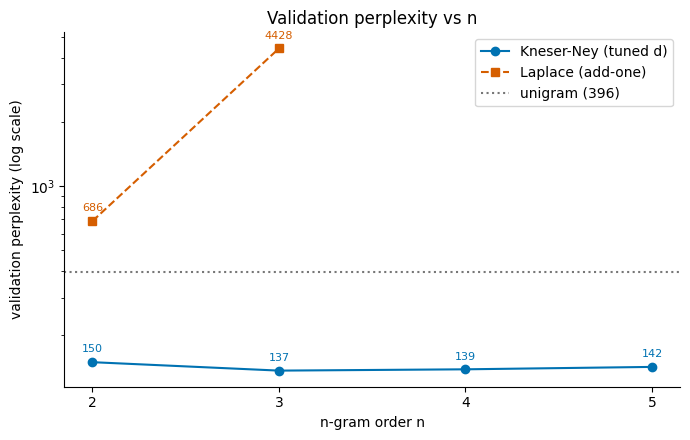

saved figure -> figures/ngram_val_topk_vs_n.png


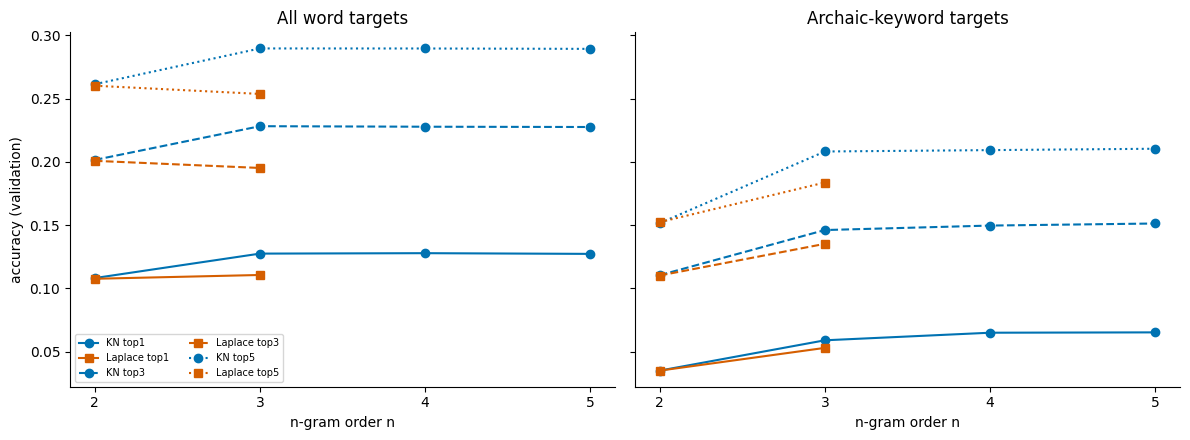

saved figure -> figures/ngram_size_and_latency_vs_n.png


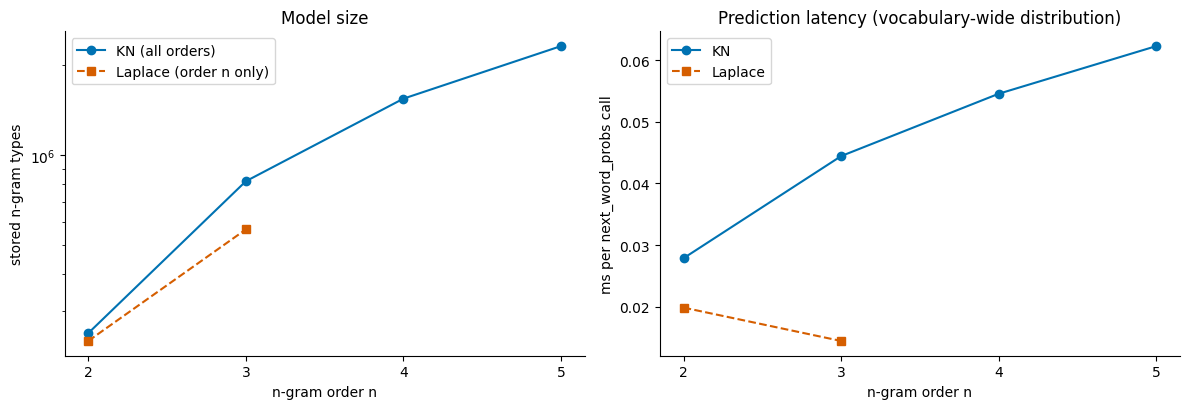

In [5]:
kn = val_df[val_df["model"].str.startswith("kn")].sort_values("n")
lap = val_df[val_df["model"].str.startswith("laplace")].sort_values("n")
uni = val_df[val_df["model"] == "unigram"].iloc[0]

# validation perplexity vs n (KN vs Laplace)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(kn["n"], kn["ppl"], "o-", color=BLUE, label="Kneser-Ney (tuned d)")
ax.plot(lap["n"], lap["ppl"], "s--", color=ORANGE, label="Laplace (add-one)")
ax.axhline(uni["ppl"], color=GREY, ls=":", label=f"unigram ({uni['ppl']:.0f})")
for x, y in zip(kn["n"], kn["ppl"]):
    ax.annotate(f"{y:.0f}", (x, y), textcoords="offset points", xytext=(0, 7), ha="center", fontsize=8, color=BLUE)
for x, y in zip(lap["n"], lap["ppl"]):
    ax.annotate(f"{y:.0f}", (x, y), textcoords="offset points", xytext=(0, 7), ha="center", fontsize=8, color=ORANGE)
ax.set_yscale("log"); ax.set_xticks([2, 3, 4, 5]); ax.set_xlabel("n-gram order n"); ax.set_ylabel("validation perplexity (log scale)")
ax.set_title("Validation perplexity vs n"); ax.legend()
plt.tight_layout(); save_fig(fig, "ngram_val_ppl_vs_n.png"); plt.show()

# top-1/3/5 accuracy vs n
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, pre, ttl in zip(axes, ["", "archaic_"], ["All word targets", "Archaic-keyword targets"]):
    for k, ls in zip(("top1", "top3", "top5"), ("-", "--", ":")):
        ax.plot(kn["n"], kn[pre + k], "o" + ls, color=BLUE, label=f"KN {k}")
        ax.plot(lap["n"], lap[pre + k], "s" + ls, color=ORANGE, label=f"Laplace {k}")
    ax.set_xticks([2, 3, 4, 5]); ax.set_xlabel("n-gram order n"); ax.set_title(ttl)
axes[0].set_ylabel("accuracy (validation)")
axes[0].legend(fontsize=7, ncol=2)
plt.tight_layout(); save_fig(fig, "ngram_val_topk_vs_n.png"); plt.show()

# stored n-grams and latency vs n
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(kn["n"], kn["num_ngrams"], "o-", color=BLUE, label="KN (all orders)")
axes[0].plot(lap["n"], lap["num_ngrams"], "s--", color=ORANGE, label="Laplace (order n only)")
axes[0].set_yscale("log"); axes[0].set_ylabel("stored n-gram types"); axes[0].set_title("Model size")
axes[1].plot(kn["n"], kn["latency_ms"], "o-", color=BLUE, label="KN")
axes[1].plot(lap["n"], lap["latency_ms"], "s--", color=ORANGE, label="Laplace")
axes[1].set_ylabel("ms per next_word_probs call"); axes[1].set_title("Prediction latency (vocabulary-wide distribution)")
for ax in axes:
    ax.set_xticks([2, 3, 4, 5]); ax.set_xlabel("n-gram order n"); ax.legend()
plt.tight_layout(); save_fig(fig, "ngram_size_and_latency_vs_n.png"); plt.show()

## 4. Choose the best *n* (validation only) and save the models
The best order is the KN model with the lowest **validation perplexity** (accuracy/KSR are shown above as a cross-check). Models are pickled to `models/` *before* the test set is touched.

In [6]:
kn = val_df[val_df["model"].str.startswith("kn")]
best_name = kn.loc[kn["ppl"].idxmin(), "model"]
best_n = int(best_name[2:])
print(f"best KN order by validation perplexity: n = {best_n}  (d = {models[best_name].d})")
cross_check = kn.set_index("model")[["ppl", "top1", "top3", "top5", "mrr", "ksr"]].round(4)
cross_check["rank_by_ppl"] = cross_check["ppl"].rank().astype(int)
cross_check["rank_by_top1"] = cross_check["top1"].rank(ascending=False).astype(int)
cross_check["rank_by_ksr"] = cross_check["ksr"].rank(ascending=False).astype(int)
display(cross_check)

for name, m in models.items():
    with open(MODEL_DIR / f"{name}.pkl", "wb") as f:
        pickle.dump(m, f)
print("saved models:", sorted(p.name for p in MODEL_DIR.glob("*.pkl")))

best KN order by validation perplexity: n = 3  (d = 0.9)


,ppl,top1,top3,top5,mrr,ksr,rank_by_ppl,rank_by_top1,rank_by_ksr
model,,,,,,,,,
kn2,149.6983,0.1082,0.2015,0.2613,0.1880,0.4690,4,4,4
kn3,136.6658,0.1275,0.2281,0.2896,0.2103,0.4789,1,2,1
kn4,138.5944,0.1279,0.2277,0.2895,0.2105,0.4788,2,1,2
kn5,142.2416,0.1273,0.2275,0.2892,0.2100,0.4787,3,3,3


saved models: ['kn2.pkl', 'kn3.pkl', 'kn4.pkl', 'kn5.pkl', 'laplace2.pkl', 'laplace3.pkl', 'unigram.pkl']


**Sanity check of the cross-sentence option (validation, not part of the main comparison).** `context="cross"` prepends the last 100 tokens of the previous sentences of the same work. An n-gram model only looks at its last *n−1* tokens, so the effect is limited to sentence beginnings; the option is there for the RNN/LSTM experiment.

In [7]:
r_sent = val_df[val_df["model"] == best_name].iloc[0]
r_cross = E.evaluate(models[best_name], "val", vocab, context="cross", cross_len=100)
cmp_ctx = pd.DataFrame([{"context": "sentence only (main)", **{k: r_sent[k] for k in ("ppl", "top1", "top3", "top5", "ksr")}},
                        {"context": "cross-sentence (last 100 tokens)", **{k: r_cross[k] for k in ("ppl", "top1", "top3", "top5", "ksr")}}])
display(cmp_ctx.round(4))
save_table(cmp_ctx, "ngram_context_mode_check.csv")

,context,ppl,top1,top3,top5,ksr
0,sentence only (main),136.6658,0.1275,0.2281,0.2896,0.4789
1,cross-sentence (last 100 tokens),136.0870,0.1275,0.2281,0.2896,0.4789


saved table  -> tables/ngram_context_mode_check.csv


## 5. Test set (evaluated once)
Only the selected KN model and the KN **bigram** baseline are evaluated on test. No tuning decision below depends on these numbers.

In [8]:
test_models = [best_name] + (["kn2"] if best_name != "kn2" else [])
test_rows = [E.evaluate(models[nm], "test", vocab) for nm in test_models]
test_df = pd.DataFrame(test_rows)
test_df["val_ppl"] = [float(val_df.loc[val_df["model"] == nm, "ppl"].iloc[0]) for nm in test_models]
tcols = ["model", "n", "hyperparameters", "ppl", "val_ppl", "top1", "top3", "top5", "mrr", "ksr", "archaic_top1", "archaic_top3",
         "archaic_top5", "archaic_mrr", "archaic_ksr", "latency_ms", "n_word_targets", "n_archaic_targets"]
display(test_df[tcols].round(4))
save_table(test_df[tcols], "ngram_test_results.csv")

,model,n,hyperparameters,ppl,val_ppl,top1,top3,top5,mrr,ksr,archaic_top1,archaic_top3,archaic_top5,archaic_mrr,archaic_ksr,latency_ms,n_word_targets,n_archaic_targets
0,kn3,3,"{""d"": 0.9}",134.6814,136.6658,0.1261,0.2246,0.2843,0.2074,0.4771,0.0651,0.1634,0.2164,0.1568,0.5091,0.0439,81229,3715
1,kn2,2,"{""d"": 0.8}",147.3810,149.6983,0.1077,0.1986,0.2554,0.1856,0.4673,0.0452,0.1332,0.1760,0.1320,0.4991,0.0283,81229,3715


saved table  -> tables/ngram_test_results.csv


## 6. Qualitative examples (test plays)
Ten prefixes from the **test** plays: five whose next word is an archaic keyword and five ordinary ones (deterministic sample, seed 42, at most two per play per kind). The table shows the best model's top-5 *word* suggestions with their probabilities from the full distribution.

In [9]:
best = models[best_name]
test_sents = D.load_split("test", vocab=vocab)
idx = D.load_works_index().query("split == 'test'")
work_of = np.zeros(len(test_sents), dtype=int)
slugs = list(idx["slug"])
for w, (_, r) in enumerate(idx.iterrows()):
    work_of[r.first_line: r.first_line + r.n_sentences] = w

arch = E.archaic_set()
cand = E.word_ids(vocab)
word_set = set(cand.tolist())
rng = random.Random(42)
pool_arch, pool_gen = [], []
for si, s in enumerate(test_sents):
    for i in range(4, len(s) - 1):                           # at least 3 words of context
        t = vocab.itos[s[i]]
        if s[i] not in word_set:
            continue
        (pool_arch if t.strip("'") in arch else pool_gen).append((si, i))


def pick(pool, k):
    rng.shuffle(pool)
    chosen, per_work = [], {}
    for si, i in pool:
        w = work_of[si]
        if per_work.get(w, 0) < 2 and len(test_sents[si]) >= 7:
            chosen.append((si, i)); per_work[w] = per_work.get(w, 0) + 1
        if len(chosen) == k:
            break
    return chosen


examples = []
for kind, pool in (("archaic next word", pool_arch), ("ordinary next word", pool_gen)):
    for si, i in pick(pool, 5):
        s = test_sents[si]
        p = best.next_word_probs(s[:i])
        pc = p[cand]
        order_ = np.lexsort((cand, -pc))                       # by probability, ties by id
        top = cand[order_[:5]]
        true = s[i]
        rank = 1 + int((pc > p[true]).sum() + ((pc == p[true]) & (cand < true)).sum())
        row = {"kind": kind, "play": slugs[work_of[si]], "prefix": " ".join(vocab.itos[t] for t in s[1:i]),
               "actual_next": vocab.itos[true], "actual_rank": rank, "in_top5": rank <= 5}
        for j, t in enumerate(top, 1):
            row[f"top{j}"] = f"{vocab.itos[t]} ({p[t]:.3f})"
        examples.append(row)
ex_df = pd.DataFrame(examples)
pd.set_option("display.max_colwidth", 70); pd.set_option("display.width", 250)
display(ex_df)
save_table(ex_df, "ngram_examples.csv")

,kind,play,prefix,actual_next,actual_rank,in_top5,top1,top2,top3,top4,top5
0,archaic next word,antony_and_cleopatra,i have seen thee fight when i have envied,thy,29,False,the (0.033),his (0.029),him (0.028),against (0.026),of (0.013)
1,archaic next word,twelfth_night_or_what_you_will,"alas , poor fool , how have they baffled",thee,37,False,here (0.052),of (0.013),and (0.012),to (0.012),in (0.010)
2,archaic next word,second_part_of_king_henry_the_sixth,"my lord ,",i'll,19,False,i (0.138),and (0.072),you (0.046),my (0.036),that (0.034)
3,archaic next word,tempest,"to the king's ship , invisible as thou art : there",shalt,207,False,is (0.463),shall (0.103),are (0.060),was (0.014),be (0.008)
4,archaic next word,antony_and_cleopatra,'tis one of those odd tricks which,sorrow,243,False,i (0.048),is (0.028),the (0.025),you (0.024),he (0.023)
5,ordinary next word,twelfth_night_or_what_you_will,"then you are mad indeed , if you be no",better,3,True,more (0.205),less (0.043),better (0.036),great (0.031),other (0.016)
6,ordinary next word,second_part_of_king_henry_the_sixth,"nay , john , it will be stinking law , for",his,13,False,i (0.095),the (0.068),my (0.040),he (0.038),a (0.033)
7,ordinary next word,tempest,"my high charms work , and these mine enemies are all knit up in th...",drown'd,1533,False,a (0.031),the (0.031),not (0.029),in (0.020),to (0.019)
8,ordinary next word,tempest,"prithee , say",on,55,False,i (0.188),you (0.099),they (0.044),what (0.043),no (0.024)
9,ordinary next word,second_part_of_king_henry_the_sixth,by devilish policy art thou grown great,and,2,True,in (0.019),and (0.018),ones (0.014),men (0.013),of (0.010)


saved table  -> tables/ngram_examples.csv


## Summary of findings

1. **Setup:** seven models trained on the 53,331 train sentences (vocabulary 14,713 with punctuation, `<unk>`, `<num>`); context = current sentence only, padded with `<s>`; model selection on validation only.
2. **Smoothing matters a lot:** validation perplexity (all tokens) is 396 for the unigram floor, 686 for Laplace-2 and 4,428 for Laplace-3 (add-one gives so much mass to unseen continuations that the trigram is *worse than the unigram*), but 149.7 / 136.7 / 138.6 / 142.2 for Kneser-Ney n = 2 / 3 / 4 / 5.
3. **Best order is n = 3** (validation perplexity 136.7, discount 0.9); higher orders do not help: perplexity rises slightly for n = 4 and 5 and top-1 accuracy is flat (12.7–12.8 % for n = 3–5). With ~1M training tokens most 4- and 5-grams are seen once (97.8 % of 4-gram types in the EDA), so extra context is mostly unseen. Accuracy and KSR agree with perplexity up to differences of 0.1 point.
4. **Discount:** tuned per order on {0.5 … 0.9}: best d = 0.8 / 0.9 / 0.9 / 0.9 for n = 2…5, rising with n. For n = 3 the optimum sits at the edge of the grid, so I checked d = 0.95, 0.98, 1.0 on validation (not used for selection): n = 3 is worse (137.3 / 139.1 / 143.4); for n = 4 and 5, d = 0.95 would gain only 0.3 and 0.8 perplexity points (< 1 %) and does not change the ranking of the orders.
5. **Word prediction (validation, KN n = 3):** top-1 / top-3 / top-5 = 12.8 / 22.8 / 29.0 %, MRR 0.210, keystroke savings 47.9 %. The unigram floor gets 3.3 / 8.8 / 13.3 % and KSR 39.7 %, i.e. most of the KSR comes from filtering suggestions by the typed prefix, and context adds about 8 points.
6. **Archaic words are harder:** on the 3,675 archaic-keyword targets of the validation set KN-3 reaches top-1 5.9 % / top-5 20.8 % (all words: 12.8 / 29.0 %); KSR is higher (50.6 %) mostly because these words are long. The qualitative table shows the typical failure: after `thou art : there` the model proposes `is, shall, are` and ranks `shalt` 207th, since it only sees the last two tokens.
7. **Test set (evaluated once):** KN-3 perplexity 134.7 (validation 136.7), top-1/3/5 = 12.6 / 22.5 / 28.4 %, MRR 0.207, KSR 47.7 %, archaic top-1/5 = 6.5 / 21.6 % (3,715 targets). The KN bigram baseline: perplexity 147.4, top-1/3/5 = 10.8 / 19.9 / 25.5 %, KSR 46.7 %. The trigram improves perplexity by 8.6 % and top-1 by 1.8 points.
8. **Cost:** every model answers in well under a millisecond with a full-vocabulary distribution (KN-3 0.044 ms, KN-5 0.062 ms per call); KN-3 stores 0.82M n-gram types, KN-5 2.3M (Laplace-3 0.56M).
9. **Cross-sentence context** (validation, option for the later RNN comparison): KN-3 perplexity 136.1 vs 136.7 and identical accuracy – an n-gram model only sees its last *n−1* tokens, so it gains nothing from earlier sentences.
10. **Caveats:** perplexity is over *all* tokens (punctuation and `</s>` included), so it is not comparable with word-only perplexities; accuracy is over word targets only and suggestions are limited to words (no punctuation); results are single runs without confidence intervals, and the archaic subset is small (≈ 3.7k targets).